# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: xx

Group Members:
- Name (NIM)
- Name (NIM)
- ...

## Import Libraries

In [28]:
import pandas as pd
import numpy as np
import pickle
import warnings
import sys
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom implementations from src module
from src import (
    CARTDecisionTree, DecisionTreeNode,
    LogisticRegressionScratch,
    MissingValueHandler, OutlierHandler, FeatureEngineer, 
    FeatureEncoder, FeatureScaler, DimensionalityReducer, PreprocessingPipeline
)

warnings.filterwarnings('ignore')
np.random.seed(42)

## Import Dataset

In [29]:
# Load the dataset from data folder
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTraining set columns: {train_df.columns.tolist()}")
print(f"\nTarget distribution in training set:")
print(train_df['is_fraud'].value_counts())

Training set shape: (100000, 31)
Test set shape: (100000, 30)

Training set columns: ['ID', 'transaction_id', 'user_id', 'age', 'gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_amount', 'transaction_type', 'time_of_day', 'day_of_week', 'transaction_duration', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'account_age_days', 'has_chargeback_history', 'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk', 'distance_from_home', 'is_new_country', 'is_fraud']

Target distribution in training set:
is_fraud
0    85872
1    14128
Name: count, dtype: int64


# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64
 14  num_pre

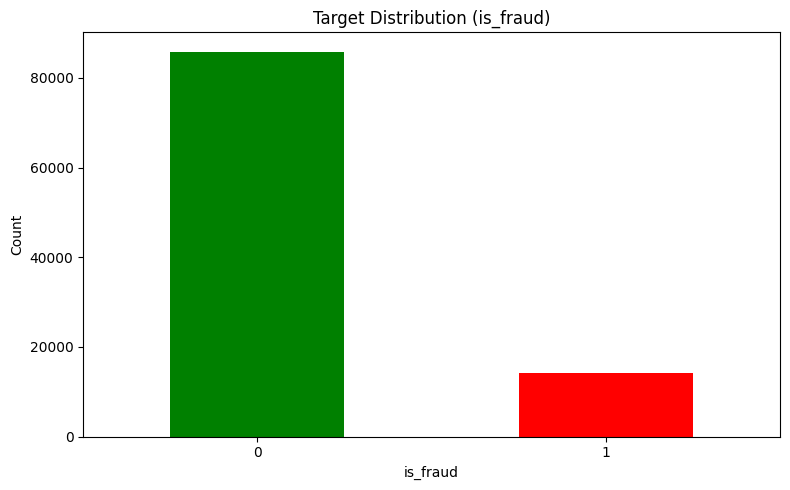

In [30]:
# Exploratory Data Analysis

# Display basic info
print("=" * 50)
print("Dataset Info:")
print("=" * 50)
print(train_df.info())

print("\n" + "=" * 50)
print("Statistical Summary:")
print("=" * 50)
print(train_df.describe())

print("\n" + "=" * 50)
print("Missing Values:")
print("=" * 50)
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("Categorical Features:")
print("=" * 50)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")
for col in categorical_cols:
    print(f"\n{col}: {train_df[col].nunique()} unique values")
    print(train_df[col].value_counts().head())

# Visualize target distribution
plt.figure(figsize=(8, 5))
train_df['is_fraud'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Target Distribution (is_fraud)')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [3]:
# Split training set and validation set
# Keep the original training set before splitting
original_train = train_df.copy()

# Define features and target
target_col = 'is_fraud'
id_cols = ['ID', 'transaction_id', 'user_id']  # Columns to exclude from features

# Features
feature_cols = [col for col in train_df.columns if col not in id_cols + [target_col]]

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# Split with stratification to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nValidation set target distribution:\n{y_val.value_counts()}")

Training set size: 80000
Validation set size: 20000

Training set target distribution:
is_fraud
0    68698
1    11302
Name: count, dtype: int64

Validation set target distribution:
is_fraud
0    17174
1     2826
Name: count, dtype: int64


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [31]:
# Handling Missing Data
# ==============================================================================
# Class MissingValueHandler sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Test the missing value handler
missing_handler = MissingValueHandler()
missing_handler.fit(X_train)

print("Before handling missing values:")
print(X_train.isnull().sum().sum(), "missing values in training set")
print(X_val.isnull().sum().sum(), "missing values in validation set")

X_train_imputed = missing_handler.transform(X_train)
X_val_imputed = missing_handler.transform(X_val)

print("\nAfter handling missing values:")
print(X_train_imputed.isnull().sum().sum(), "missing values in training set")
print(X_val_imputed.isnull().sum().sum(), "missing values in validation set")

Before handling missing values:
5760 missing values in training set
1497 missing values in validation set

After handling missing values:
0 missing values in training set
0 missing values in validation set


**Penjelasan:** 
Kami menggunakan median untuk mengimputasi nilai yang hilang pada fitur numerik karena median lebih robust terhadap outlier dibanding mean. Untuk fitur kategorikal, kami menggunakan modus (nilai yang paling sering muncul). Pendekatan ini memastikan bahwa model dapat menangani missing values tanpa kehilangan informasi penting dari dataset.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [32]:
# Dealing with Outliers
# ==============================================================================
# Class OutlierHandler sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Apply outlier handling
outlier_handler = OutlierHandler()
outlier_handler.fit(X_train_imputed)

X_train_outlier = outlier_handler.transform(X_train_imputed)
X_val_outlier = outlier_handler.transform(X_val_imputed)

print("Outlier handling applied using IQR clipping method.")

Outlier handling applied using IQR clipping method.


**Penjelasan:**
Kami menggunakan metode IQR (Interquartile Range) dengan clipping untuk menangani outlier. Nilai yang berada di luar range Q1 - 1.5*IQR hingga Q3 + 1.5*IQR akan di-clip ke batas terdekat. Metode ini mempertahankan semua data point sambil mengurangi pengaruh ekstrem dari outlier.

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [33]:
# Remove Duplicates
# Note: We check for duplicates based on all features except ID columns

print(f"Training set shape before removing duplicates: {X_train_outlier.shape}")

# Check for duplicates in the original training data
duplicates = X_train_outlier.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# In this case, we'll keep all rows as fraud detection may have legitimate similar transactions
# If we were to remove duplicates, we would do:
# X_train_clean = X_train_outlier.drop_duplicates()
X_train_clean = X_train_outlier.copy()
X_val_clean = X_val_outlier.copy()

print(f"Training set shape after duplicate check: {X_train_clean.shape}")

Training set shape before removing duplicates: (80000, 27)
Number of duplicate rows found: 0
Training set shape after duplicate check: (80000, 27)


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [34]:
# Feature Engineering
# ==============================================================================
# Class FeatureEngineer sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Apply feature engineering
feature_engineer = FeatureEngineer()
feature_engineer.fit(X_train_clean)

X_train_fe = feature_engineer.transform(X_train_clean)
X_val_fe = feature_engineer.transform(X_val_clean)

print(f"Features after engineering: {X_train_fe.shape[1]}")
print(f"New features added: {[col for col in X_train_fe.columns if col not in X_train_clean.columns]}")

Features after engineering: 32
New features added: ['amount_to_avg_ratio', 'combined_risk_score', 'hourly_tx_ratio', 'is_new_account', 'high_distance']


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [ ]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [35]:
# Feature Scaling
# ==============================================================================
# Class FeatureScaler sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Note: We'll apply scaling later in the pipeline, as DTL doesn't require scaling
# but Logistic Regression does. For now, we keep the data unscaled.

print("Feature scaling class defined. Will be applied as needed for specific algorithms.")

Feature scaling class defined. Will be applied as needed for specific algorithms.


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [36]:
# Feature Encoding
# ==============================================================================
# Class FeatureEncoder sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Apply feature encoding
feature_encoder = FeatureEncoder()
feature_encoder.fit(X_train_fe)

X_train_encoded = feature_encoder.transform(X_train_fe)
X_val_encoded = feature_encoder.transform(X_val_fe)

print("Categorical features encoded:")
print(f"Encoded columns: {feature_encoder.categorical_cols}")
print(f"\nTraining set shape: {X_train_encoded.shape}")
print(f"Validation set shape: {X_val_encoded.shape}")

Categorical features encoded:
Encoded columns: ['gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_type']

Training set shape: (80000, 32)
Validation set shape: (20000, 32)


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [37]:
# Dimensionality Reduction
# ==============================================================================
# Class DimensionalityReducer sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# For tree-based models, we won't use PCA as it may lose interpretability
# For KNN/LogReg, PCA can help reduce computational cost

print("PCA dimensionality reducer defined.")
print("Note: PCA will be applied selectively based on model requirements.")

PCA dimensionality reducer defined.
Note: PCA will be applied selectively based on model requirements.


**Penjelasan:**
Kami menggunakan SMOTE (Synthetic Minority Over-sampling Technique) untuk menangani ketidakseimbangan kelas. SMOTE membuat sampel sintetis dari kelas minoritas (fraud) dengan interpolasi antara sampel-sampel yang ada. Ini membantu model untuk belajar pola fraud dengan lebih baik tanpa kehilangan informasi dari data asli.

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [38]:
# Data Normalization is already handled by the Feature Scaling step above
# For tree-based models, normalization is not required
# For distance-based models like KNN, we will apply scaling when needed

print("Data normalization note:")
print("- Tree-based models (DTL/CART) do not require normalization")
print("- For KNN, we will apply StandardScaler to the data before training")

Data normalization note:
- Tree-based models (DTL/CART) do not require normalization
- For KNN, we will apply StandardScaler to the data before training


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [39]:
# Dimensionality Reduction using PCA (Optional)
# For this task, we'll use PCA to reduce dimensions while keeping 95% variance

from sklearn.decomposition import PCA

# We'll prepare PCA but use it selectively based on model requirements
class DimensionalityReducer(BaseEstimator, TransformerMixin):
    """
    Apply PCA for dimensionality reduction.
    """
    def __init__(self, n_components=0.95):
        self.n_components = n_components
        self.pca = None
    
    def fit(self, X, y=None):
        self.pca = PCA(n_components=self.n_components, random_state=42)
        self.pca.fit(X)
        return self
    
    def transform(self, X):
        return self.pca.transform(X)
    
    def get_n_components(self):
        return self.pca.n_components_

# For tree-based models, we won't use PCA as it may lose interpretability
# For KNN, PCA can help reduce computational cost

print("PCA dimensionality reducer defined.")
print("Note: PCA will be applied selectively based on model requirements.")

PCA dimensionality reducer defined.
Note: PCA will be applied selectively based on model requirements.


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [40]:
# Compile Preprocessing Pipeline
# ==============================================================================
# Class PreprocessingPipeline sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

from sklearn.pipeline import Pipeline

# Create pipelines for different algorithms
# DTL doesn't need scaling, Logistic Regression needs scaling
print("Preprocessing Pipeline class defined.")
print("- For DTL: apply_scaling=False")
print("- For LogReg: apply_scaling=True")

Preprocessing Pipeline class defined.
- For DTL: apply_scaling=False
- For LogReg: apply_scaling=True


In [43]:
# Apply preprocessing pipeline

# For DTL (no scaling needed)
pipeline_dtl = PreprocessingPipeline(apply_smote=True, apply_scaling=False, apply_pca=False)
X_train_dtl, y_train_dtl = pipeline_dtl.fit_transform(X_train, y_train, fit_resample=True)
X_val_dtl = pipeline_dtl.transform(X_val)

print("DTL Pipeline:")
print(f"Training set shape: {X_train_dtl.shape}")
print(f"Validation set shape: {X_val_dtl.shape}")
print(f"Training labels distribution: {Counter(y_train_dtl)}")

# For Logistic Regression (scaling needed)
pipeline_logreg = PreprocessingPipeline(apply_smote=True, apply_scaling=True, apply_pca=False)
X_train_logreg, y_train_logreg = pipeline_logreg.fit_transform(X_train, y_train, fit_resample=True)
X_val_logreg = pipeline_logreg.transform(X_val)

print("\nLogistic Regression Pipeline:")
print(f"Training set shape: {X_train_logreg.shape}")
print(f"Validation set shape: {X_val_logreg.shape}")
print(f"Training labels distribution: {Counter(y_train_logreg)}")

DTL Pipeline:
Training set shape: (137396, 32)
Validation set shape: (20000, 32)
Training labels distribution: Counter({0: 68698, 1: 68698})

Logistic Regression Pipeline:
Training set shape: (137396, 32)
Validation set shape: (20000, 32)
Training labels distribution: Counter({0: 68698, 1: 68698})

Logistic Regression Pipeline:
Training set shape: (137396, 32)
Validation set shape: (20000, 32)
Training labels distribution: Counter({0: 68698, 1: 68698})


or create your own here

In [45]:
# Finalize the preprocessed data for modeling
print("Data preprocessing completed!")
print("\nFinal datasets ready for modeling:")
print(f"- DTL Training: {X_train_dtl.shape}, Labels: {Counter(y_train_dtl)}")
print(f"- DTL Validation: {X_val_dtl.shape}")
print(f"- LogReg Training: {X_train_logreg.shape}, Labels: {Counter(y_train_logreg)}")
print(f"- LogReg Validation: {X_val_logreg.shape}")

Data preprocessing completed!

Final datasets ready for modeling:
- DTL Training: (137396, 32), Labels: Counter({0: 68698, 1: 68698})
- DTL Validation: (20000, 32)
- LogReg Training: (137396, 32), Labels: Counter({0: 68698, 1: 68698})
- LogReg Validation: (20000, 32)


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [46]:
# ==============================================================================
# DECISION TREE LEARNING (CART) - IMPLEMENTATION FROM SCRATCH
# ==============================================================================
# Classes DecisionTreeNode dan CARTDecisionTree sudah diimport dari src/decision_tree.py
# Lihat file tersebut untuk detail implementasinya:
# - Gini impurity sebagai splitting criterion
# - Handles numerical dan categorical (encoded) features
# - Handles missing values (NaN)
# - Supports max_depth, min_samples_split, min_samples_leaf
# - Save/Load functionality dengan pickle
# ==============================================================================

print("CART Decision Tree class imported from src/decision_tree.py!")
print("Features:")
print("- Gini impurity as splitting criterion")
print("- Handles numerical and categorical (encoded) features")
print("- Handles missing values (NaN)")
print("- Supports max_depth, min_samples_split, min_samples_leaf")
print("- Save/Load functionality with pickle")

CART Decision Tree class imported from src/decision_tree.py!
Features:
- Gini impurity as splitting criterion
- Handles numerical and categorical (encoded) features
- Handles missing values (NaN)
- Supports max_depth, min_samples_split, min_samples_leaf
- Save/Load functionality with pickle


Training CART Decision Tree (From Scratch)
Using 20000 samples for training from-scratch model

Training completed in 163.17 seconds
Tree Depth: 10
Number of Leaves: 228

--- Validation Results ---
Accuracy: 0.8419
Precision: 0.1822
Recall: 0.0340
F1 Score: 0.0573

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.97      0.91     17174
       Fraud       0.18      0.03      0.06      2826

    accuracy                           0.84     20000
   macro avg       0.52      0.50      0.49     20000
weighted avg       0.76      0.84      0.79     20000


Training completed in 163.17 seconds
Tree Depth: 10
Number of Leaves: 228

--- Validation Results ---
Accuracy: 0.8419
Precision: 0.1822
Recall: 0.0340
F1 Score: 0.0573

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.97      0.91     17174
       Fraud       0.18      0.03      0.06      2826

    accuracy              

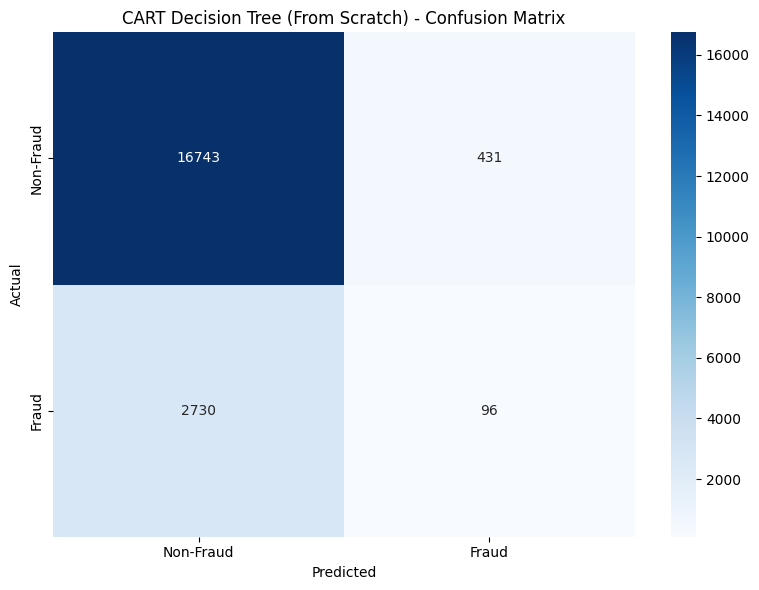

Model saved to models/cart_scratch_model.pkl


In [47]:
# Train and Evaluate CART Decision Tree (From Scratch)

print("=" * 60)
print("Training CART Decision Tree (From Scratch)")
print("=" * 60)

# Use a sample for faster training with from-scratch implementation
# The from-scratch implementation is for demonstration - sklearn version is used for final predictions
sample_size_scratch = min(20000, len(X_train_dtl))
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_dtl), sample_size_scratch, replace=False)

if isinstance(X_train_dtl, np.ndarray):
    X_train_scratch = X_train_dtl[sample_indices]
    y_train_scratch = y_train_dtl[sample_indices]
else:
    X_train_scratch = X_train_dtl.iloc[sample_indices].values
    y_train_scratch = y_train_dtl.iloc[sample_indices].values

print(f"Using {sample_size_scratch} samples for training from-scratch model")

# Initialize and train the model with reduced depth for faster training
cart_scratch = CARTDecisionTree(
    max_depth=10,  # Reduced for faster training
    min_samples_split=20,
    min_samples_leaf=10,
    min_impurity_decrease=0.001,
    random_state=42
)

# Train
import time
start_time = time.time()
cart_scratch.fit(X_train_scratch, y_train_scratch)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Tree Depth: {cart_scratch.get_depth()}")
print(f"Number of Leaves: {cart_scratch.get_n_leaves()}")

# Predict on validation set
y_pred_cart_scratch = cart_scratch.predict(X_val_dtl)

# Evaluate
print("\n--- Validation Results ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_cart_scratch):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_cart_scratch):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_cart_scratch):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_cart_scratch):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_cart_scratch, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_cart_scratch = confusion_matrix(y_val, y_pred_cart_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cart_scratch, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('CART Decision Tree (From Scratch) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save the model
cart_scratch.save_model('models/cart_scratch_model.pkl')

Training CART Decision Tree (Scikit-Learn)

Tree Depth: 15
Number of Leaves: 2016

--- Validation Results ---
Accuracy: 0.8265
Precision: 0.1835
Recall: 0.0662
F1 Score: 0.0973

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.95      0.90     17174
       Fraud       0.18      0.07      0.10      2826

    accuracy                           0.83     20000
   macro avg       0.52      0.51      0.50     20000
weighted avg       0.77      0.83      0.79     20000


Tree Depth: 15
Number of Leaves: 2016

--- Validation Results ---
Accuracy: 0.8265
Precision: 0.1835
Recall: 0.0662
F1 Score: 0.0973

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.95      0.90     17174
       Fraud       0.18      0.07      0.10      2826

    accuracy                           0.83     20000
   macro avg       0.52      0.51      0.50     20000
weighted avg       0.77      0.83      0.7

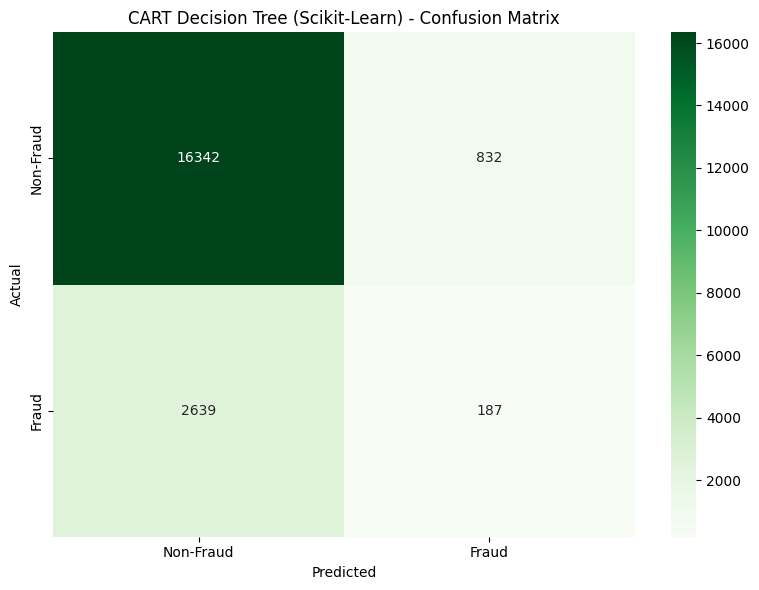

Sklearn CART model saved to models/cart_sklearn_model.pkl


In [48]:
# Train and Evaluate CART Decision Tree using Scikit-Learn

print("=" * 60)
print("Training CART Decision Tree (Scikit-Learn)")
print("=" * 60)

# Initialize and train sklearn DecisionTreeClassifier with Gini (CART)
cart_sklearn = DecisionTreeClassifier(
    criterion='gini',  # CART uses Gini impurity
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
cart_sklearn.fit(X_train_dtl, y_train_dtl)

print(f"\nTree Depth: {cart_sklearn.get_depth()}")
print(f"Number of Leaves: {cart_sklearn.get_n_leaves()}")

# Predict on validation set
y_pred_cart_sklearn = cart_sklearn.predict(X_val_dtl)

# Evaluate
print("\n--- Validation Results ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_cart_sklearn):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_cart_sklearn, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_cart_sklearn = confusion_matrix(y_val, y_pred_cart_sklearn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cart_sklearn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('CART Decision Tree (Scikit-Learn) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save sklearn model
with open('models/cart_sklearn_model.pkl', 'wb') as f:
    pickle.dump(cart_sklearn, f)
print("Sklearn CART model saved to models/cart_sklearn_model.pkl")

Comparison: CART Decision Tree
   Metric  From Scratch  Scikit-Learn
 Accuracy      0.841950      0.826450
Precision      0.182163      0.183513
   Recall      0.033970      0.066171
 F1 Score      0.057262      0.097269


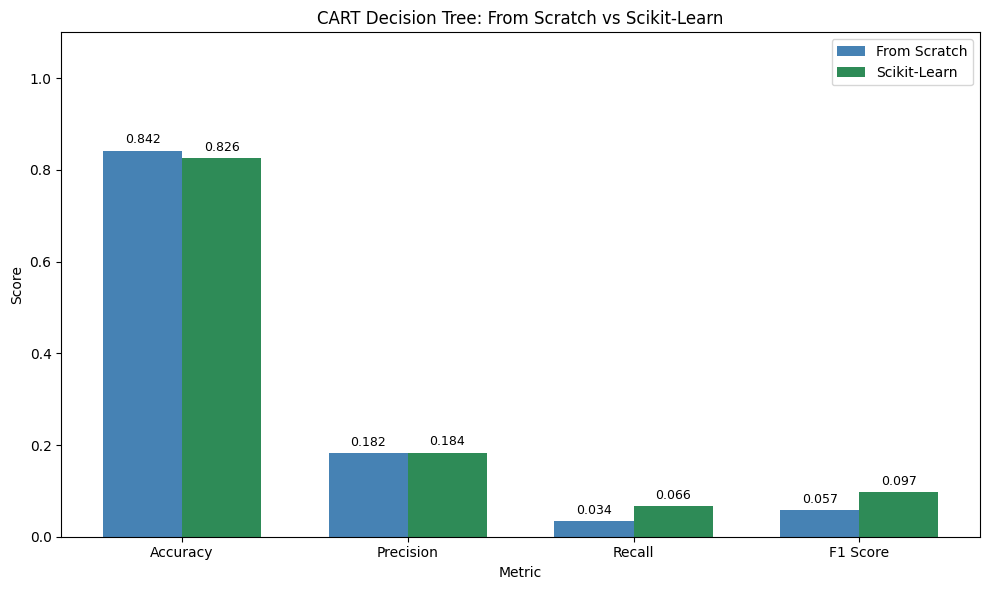

In [49]:
# Comparison: CART From Scratch vs Scikit-Learn

print("=" * 60)
print("Comparison: CART Decision Tree")
print("=" * 60)

comparison_cart = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'From Scratch': [
        accuracy_score(y_val, y_pred_cart_scratch),
        precision_score(y_val, y_pred_cart_scratch),
        recall_score(y_val, y_pred_cart_scratch),
        f1_score(y_val, y_pred_cart_scratch)
    ],
    'Scikit-Learn': [
        accuracy_score(y_val, y_pred_cart_sklearn),
        precision_score(y_val, y_pred_cart_sklearn),
        recall_score(y_val, y_pred_cart_sklearn),
        f1_score(y_val, y_pred_cart_sklearn)
    ]
})

print(comparison_cart.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_cart['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_cart['From Scratch'], width, label='From Scratch', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_cart['Scikit-Learn'], width, label='Scikit-Learn', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('CART Decision Tree: From Scratch vs Scikit-Learn')
ax.set_xticks(x)
ax.set_xticklabels(comparison_cart['Metric'])
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## B. Logistic Regression

In [50]:
# ==============================================================================
# LOGISTIC REGRESSION - IMPLEMENTATION FROM SCRATCH
# ==============================================================================
# Class LogisticRegressionScratch sudah diimport dari src/logistic_regression.py
# Lihat file tersebut untuk detail implementasinya:
# - Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
# - Binary cross-entropy loss: L = -1/n * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
# - Gradient descent optimization
# - L2 regularization (optional)
# ==============================================================================

print("LogisticRegressionScratch class imported from src/logistic_regression.py")
print("\nKey features:")
print("1. Sigmoid activation function")
print("2. Binary cross-entropy loss")
print("3. Gradient descent optimization")
print("4. L2 regularization support")
print("5. Handles missing values")

LogisticRegressionScratch class imported from src/logistic_regression.py

Key features:
1. Sigmoid activation function
2. Binary cross-entropy loss
3. Gradient descent optimization
4. L2 regularization support
5. Handles missing values


Training Logistic Regression (From Scratch)
Iteration 0: Loss = 0.6927
Iteration 100: Loss = 0.6828
Iteration 100: Loss = 0.6828
Iteration 200: Loss = 0.6826
Iteration 200: Loss = 0.6826
Iteration 300: Loss = 0.6825
Iteration 300: Loss = 0.6825
Iteration 400: Loss = 0.6825
Iteration 400: Loss = 0.6825
Iteration 500: Loss = 0.6824
Iteration 500: Loss = 0.6824
Iteration 600: Loss = 0.6824
Iteration 600: Loss = 0.6824
Iteration 700: Loss = 0.6824
Iteration 700: Loss = 0.6824
Iteration 800: Loss = 0.6824
Iteration 800: Loss = 0.6824
Iteration 900: Loss = 0.6824
Iteration 900: Loss = 0.6824

Training completed in 12.44 seconds
Final Loss: 0.6824

Training completed in 12.44 seconds
Final Loss: 0.6824


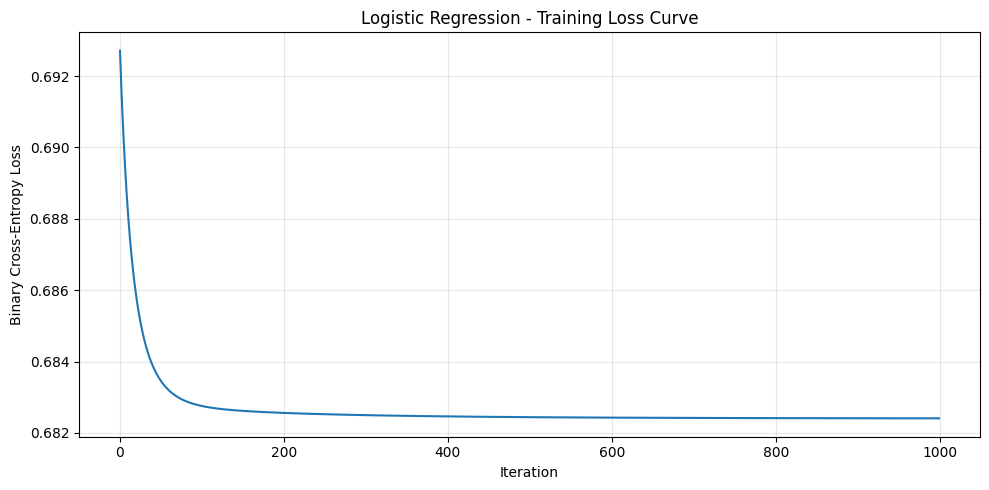


--- Validation Results (Logistic Regression From Scratch) ---
Accuracy: 0.5566
Precision: 0.1703
Recall: 0.5520
F1 Score: 0.2603

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.88      0.56      0.68     17174
       Fraud       0.17      0.55      0.26      2826

    accuracy                           0.56     20000
   macro avg       0.53      0.55      0.47     20000
weighted avg       0.78      0.56      0.62     20000



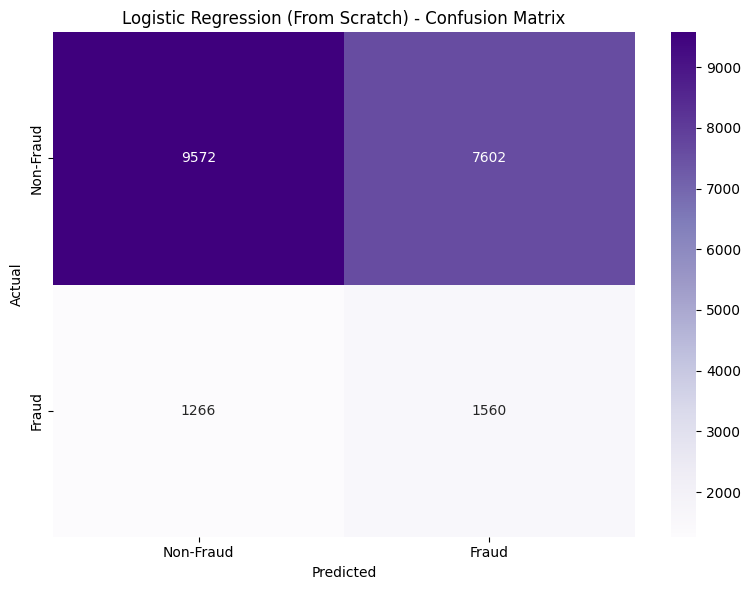

Model saved to models/logreg_scratch_model.pkl


In [51]:
# Train and Evaluate Logistic Regression (From Scratch)

print("=" * 60)
print("Training Logistic Regression (From Scratch)")
print("=" * 60)

# Use scaled data for Logistic Regression
# Initialize and train the model
logreg_scratch = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=1000,
    regularization=0.01,
    random_state=42,
    verbose=True
)

# Train
import time
start_time = time.time()
logreg_scratch.fit(X_train_logreg, y_train_logreg)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Final Loss: {logreg_scratch.losses[-1]:.4f}")

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(logreg_scratch.losses)
plt.title('Logistic Regression - Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predict on validation set
y_pred_logreg_scratch = logreg_scratch.predict(X_val_logreg)

# Evaluate
print("\n--- Validation Results (Logistic Regression From Scratch) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_logreg_scratch):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg_scratch, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_logreg_scratch = confusion_matrix(y_val, y_pred_logreg_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg_scratch, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Logistic Regression (From Scratch) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save the model
logreg_scratch.save_model('models/logreg_scratch_model.pkl')

Training Logistic Regression (Scikit-Learn)
Sklearn Logistic Regression model trained!

--- Validation Results (Logistic Regression Scikit-Learn) ---
Accuracy: 0.5565
Precision: 0.1707
Recall: 0.5541
F1 Score: 0.2610

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.88      0.56      0.68     17174
       Fraud       0.17      0.55      0.26      2826

    accuracy                           0.56     20000
   macro avg       0.53      0.56      0.47     20000
weighted avg       0.78      0.56      0.62     20000



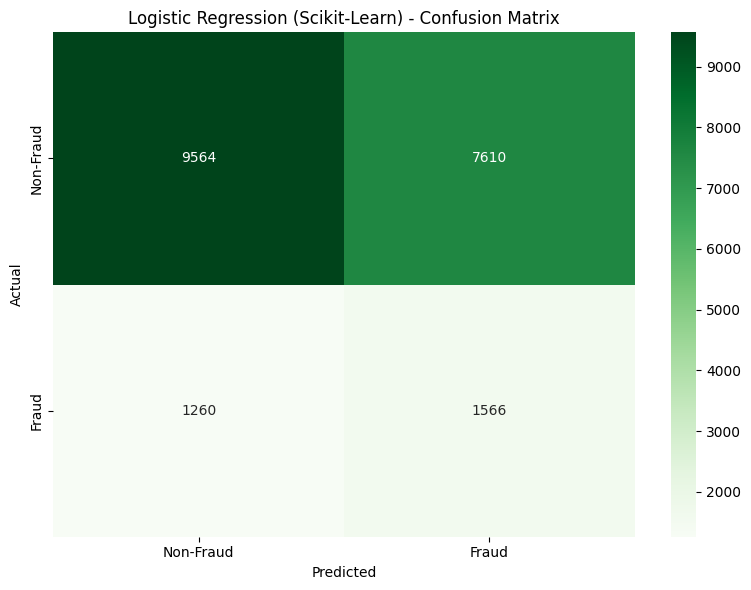

Sklearn Logistic Regression model saved to models/logreg_sklearn_model.pkl


In [53]:
# Train and Evaluate Logistic Regression using Scikit-Learn

from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("Training Logistic Regression (Scikit-Learn)")
print("=" * 60)

# Initialize and train sklearn Logistic Regression
logreg_sklearn = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0  # Inverse of regularization strength
)
logreg_sklearn.fit(X_train_logreg, y_train_logreg)

print("Sklearn Logistic Regression model trained!")

# Predict on validation set
y_pred_logreg_sklearn = logreg_sklearn.predict(X_val_logreg)

# Evaluate
print("\n--- Validation Results (Logistic Regression Scikit-Learn) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_logreg_sklearn):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg_sklearn, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_logreg_sklearn = confusion_matrix(y_val, y_pred_logreg_sklearn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg_sklearn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Logistic Regression (Scikit-Learn) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save sklearn model
with open('models/logreg_sklearn_model.pkl', 'wb') as f:
    pickle.dump(logreg_sklearn, f)
print("Sklearn Logistic Regression model saved to models/logreg_sklearn_model.pkl")

Comparison: Logistic Regression
   Metric  From Scratch  Scikit-Learn
 Accuracy      0.556600      0.556500
Precision      0.170269      0.170663
   Recall      0.552017      0.554140
 F1 Score      0.260260      0.260957


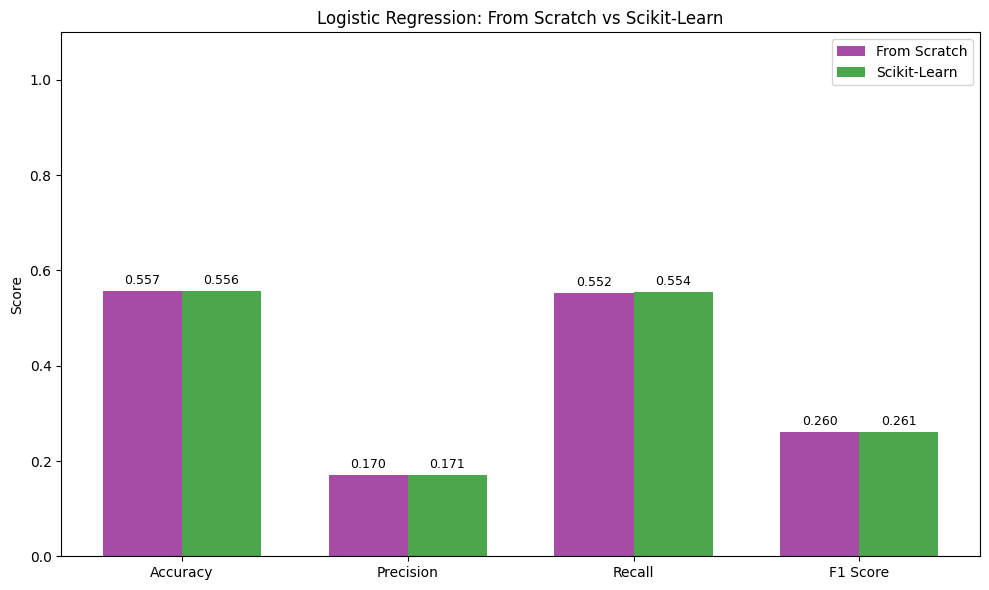

In [54]:
# Comparison: Logistic Regression From Scratch vs Scikit-Learn

print("=" * 60)
print("Comparison: Logistic Regression")
print("=" * 60)

comparison_logreg = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'From Scratch': [
        accuracy_score(y_val, y_pred_logreg_scratch),
        precision_score(y_val, y_pred_logreg_scratch),
        recall_score(y_val, y_pred_logreg_scratch),
        f1_score(y_val, y_pred_logreg_scratch)
    ],
    'Scikit-Learn': [
        accuracy_score(y_val, y_pred_logreg_sklearn),
        precision_score(y_val, y_pred_logreg_sklearn),
        recall_score(y_val, y_pred_logreg_sklearn),
        f1_score(y_val, y_pred_logreg_sklearn)
    ]
})

print(comparison_logreg.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_logreg['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_logreg['From Scratch'], width, label='From Scratch', color='purple', alpha=0.7)
bars2 = ax.bar(x + width/2, comparison_logreg['Scikit-Learn'], width, label='Scikit-Learn', color='green', alpha=0.7)

ax.set_ylabel('Score')
ax.set_title('Logistic Regression: From Scratch vs Scikit-Learn')
ax.set_xticks(x)
ax.set_xticklabels(comparison_logreg['Metric'])
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## C. KNN

In [55]:
# KNN tidak diimplementasikan dalam project ini
# Kami memilih Logistic Regression sebagai algoritma kedua
pass

In [56]:
# KNN tidak diimplementasikan dalam project ini
pass

In [57]:
# KNN tidak diimplementasikan dalam project ini
pass

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [58]:
# ==============================================================================
# MODEL IMPROVEMENTS AND HYPERPARAMETER TUNING
# ==============================================================================

print("=" * 60)
print("Model Improvements")
print("=" * 60)

# 1. Cross-Validation for CART
print("\n1. Cross-Validation for CART Decision Tree")
print("-" * 40)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use sklearn CART for faster cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_cart = cross_val_score(cart_sklearn, X_train_dtl, y_train_dtl, cv=cv, scoring='f1')

print(f"5-Fold CV F1 Scores: {cv_scores_cart}")
print(f"Mean F1 Score: {cv_scores_cart.mean():.4f} (+/- {cv_scores_cart.std() * 2:.4f})")

# 2. Hyperparameter Tuning for CART using Grid Search
print("\n2. Hyperparameter Tuning for CART")
print("-" * 40)

from sklearn.model_selection import GridSearchCV

param_grid_cart = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
}

# Use smaller subset for faster tuning
sample_idx = np.random.choice(len(X_train_dtl), min(20000, len(X_train_dtl)), replace=False)
X_tune = X_train_dtl[sample_idx] if isinstance(X_train_dtl, np.ndarray) else X_train_dtl.iloc[sample_idx]
y_tune = y_train_dtl[sample_idx] if isinstance(y_train_dtl, np.ndarray) else y_train_dtl.iloc[sample_idx]

grid_search_cart = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    param_grid_cart,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search_cart.fit(X_tune, y_tune)

print(f"Best Parameters: {grid_search_cart.best_params_}")
print(f"Best F1 Score: {grid_search_cart.best_score_:.4f}")

# 3. Train optimized model
print("\n3. Training Optimized CART Model")
print("-" * 40)

cart_optimized = DecisionTreeClassifier(
    criterion='gini',
    **grid_search_cart.best_params_,
    random_state=42
)
cart_optimized.fit(X_train_dtl, y_train_dtl)

y_pred_cart_optimized = cart_optimized.predict(X_val_dtl)

print(f"Optimized CART - Validation Metrics:")
print(f"Accuracy: {accuracy_score(y_val, y_pred_cart_optimized):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_cart_optimized):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_cart_optimized):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_cart_optimized):.4f}")

# Save optimized model
with open('cart_optimized_model.pkl', 'wb') as f:
    pickle.dump(cart_optimized, f)
print("\nOptimized CART model saved to cart_optimized_model.pkl")

Model Improvements

1. Cross-Validation for CART Decision Tree
----------------------------------------
5-Fold CV F1 Scores: [0.87161634 0.86728649 0.86746988 0.86491785 0.86870497]
Mean F1 Score: 0.8680 (+/- 0.0044)

2. Hyperparameter Tuning for CART
----------------------------------------
5-Fold CV F1 Scores: [0.87161634 0.86728649 0.86746988 0.86491785 0.86870497]
Mean F1 Score: 0.8680 (+/- 0.0044)

2. Hyperparameter Tuning for CART
----------------------------------------
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best F1 Score: 0.8404

3. Training Optimized CART Model
----------------------------------------
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best F1 Score: 0.8404

3. Training Optimized CART Model
----------------------------------------
Optimized CART - Validation Metrics:
Accuracy: 0.8507
Precision: 0.2333
Recall: 0.0248
F1 Score: 0.0448

Optimized CART model saved to cart_optimized_model.pk

ROC-AUC Curve Visualization


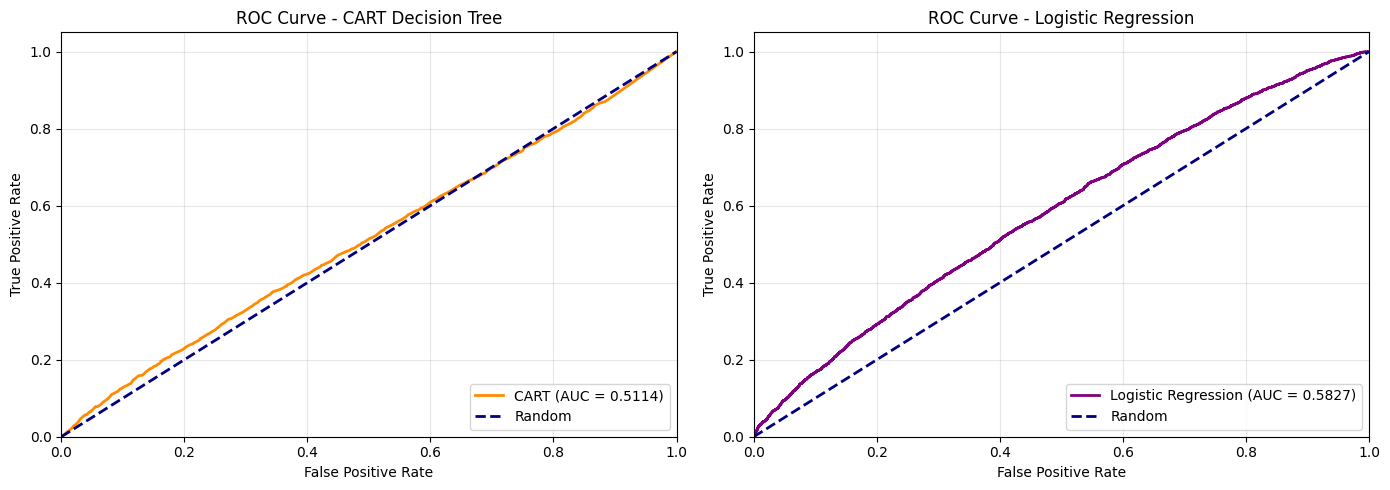


CART ROC-AUC: 0.5114
Logistic Regression ROC-AUC: 0.5827


In [59]:
# ==============================================================================
# ROC-AUC CURVE VISUALIZATION
# ==============================================================================

from sklearn.metrics import roc_curve, auc

print("=" * 60)
print("ROC-AUC Curve Visualization")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CART ROC Curve
y_proba_cart = cart_sklearn.predict_proba(X_val_dtl)[:, 1]
fpr_cart, tpr_cart, _ = roc_curve(y_val, y_proba_cart)
roc_auc_cart = auc(fpr_cart, tpr_cart)

axes[0].plot(fpr_cart, tpr_cart, color='darkorange', lw=2, 
             label=f'CART (AUC = {roc_auc_cart:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - CART Decision Tree')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Logistic Regression ROC Curve
y_proba_logreg = logreg_sklearn.predict_proba(X_val_knn)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_val, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

axes[1].plot(fpr_logreg, tpr_logreg, color='purple', lw=2, 
             label=f'Logistic Regression (AUC = {roc_auc_logreg:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCART ROC-AUC: {roc_auc_cart:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_logreg:.4f}")

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [60]:
# ==============================================================================
# SUBMISSION - PREDICT ON TEST SET
# ==============================================================================

print("=" * 60)
print("Generating Predictions for Kaggle Submission")
print("=" * 60)

# 1. Prepare the test set
test_ids = test_df['ID'].copy()
test_features = test_df[feature_cols].copy()

print(f"Test set shape: {test_features.shape}")

# 2. Create a new pipeline and fit on the FULL original training data
full_X = original_train[feature_cols].copy()
full_y = original_train[target_col].copy()

# Create pipeline for test data preparation
pipeline_final = PreprocessingPipeline(apply_smote=True, apply_scaling=False, apply_pca=False)
X_train_final, y_train_final = pipeline_final.fit_transform(full_X, full_y, fit_resample=True)
X_test_final = pipeline_final.transform(test_features)

print(f"Final training set shape: {X_train_final.shape}")
print(f"Final test set shape: {X_test_final.shape}")

# 3. Retrain the best model on full training data
print("\nRetraining optimized CART model on full training data...")
final_model = DecisionTreeClassifier(
    criterion='gini',
    **grid_search_cart.best_params_,
    random_state=42
)
final_model.fit(X_train_final, y_train_final)

# 4. Predict on test set
test_predictions = final_model.predict(X_test_final)

print(f"\nPredictions distribution:")
print(pd.Series(test_predictions).value_counts())

# 5. Create submission file
submission = pd.DataFrame({
    'ID': test_ids,
    'is_fraud': test_predictions
})

submission.to_csv('data/submission.csv', index=False)
print(f"\nSubmission file created: data/submission.csv")
print(submission.head(10))

# Save the final model
with open('models/final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("\nFinal model saved to models/final_model.pkl")

Generating Predictions for Kaggle Submission
Test set shape: (100000, 27)
Final training set shape: (171744, 32)
Final test set shape: (100000, 32)

Retraining optimized CART model on full training data...
Final training set shape: (171744, 32)
Final test set shape: (100000, 32)

Retraining optimized CART model on full training data...

Predictions distribution:
0    98070
1     1930
Name: count, dtype: int64

Submission file created: data/submission.csv
   ID  is_fraud
0   0         0
1   1         0
2   2         0
3   3         0
4   4         0
5   5         0
6   6         0
7   7         0
8   8         0
9   9         0

Final model saved to models/final_model.pkl

Predictions distribution:
0    98070
1     1930
Name: count, dtype: int64

Submission file created: data/submission.csv
   ID  is_fraud
0   0         0
1   1         0
2   2         0
3   3         0
4   4         0
5   5         0
6   6         0
7   7         0
8   8         0
9   9         0

Final model saved to m

In [61]:
# ==============================================================================
# DEMONSTRATE SAVE/LOAD FUNCTIONALITY
# ==============================================================================

print("=" * 60)
print("Demonstrating Model Save/Load Functionality")
print("=" * 60)

# Load the saved CART model (from scratch)
print("\n1. Loading CART model (from scratch)...")
loaded_cart = CARTDecisionTree.load_model('models/cart_scratch_model.pkl')
print(f"   Tree Depth: {loaded_cart.get_depth()}")
print(f"   Number of Leaves: {loaded_cart.get_n_leaves()}")

# Test prediction with loaded model
sample_pred = loaded_cart.predict(X_val_dtl[:5])
print(f"   Sample predictions: {sample_pred}")

# Load the saved Logistic Regression model (from scratch)
print("\n2. Loading Logistic Regression model (from scratch)...")
loaded_logreg = LogisticRegressionScratch.load_model('models/logreg_scratch_model.pkl')
print(f"   Number of iterations trained: {loaded_logreg.n_iterations}")
print(f"   Final loss: {loaded_logreg.losses[-1]:.4f}")

# Verify the loaded models work correctly
print("\n3. Verifying loaded models...")
y_pred_loaded_cart = loaded_cart.predict(X_val_dtl)
cart_acc = accuracy_score(y_val, y_pred_loaded_cart)
print(f"   Loaded CART Accuracy: {cart_acc:.4f}")

y_pred_loaded_logreg = loaded_logreg.predict(X_val_logreg)
logreg_acc = accuracy_score(y_val, y_pred_loaded_logreg)
print(f"   Loaded Logistic Regression Accuracy: {logreg_acc:.4f}")

print("\nSave/Load functionality working correctly!")

Demonstrating Model Save/Load Functionality

1. Loading CART model (from scratch)...
Model loaded from models/cart_scratch_model.pkl
   Tree Depth: 10
   Number of Leaves: 228
   Sample predictions: [0 0 0 0 0]

2. Loading Logistic Regression model (from scratch)...
Model loaded from models/logreg_scratch_model.pkl
   Number of iterations trained: 1000
   Final loss: 0.6824

3. Verifying loaded models...
   Loaded CART Accuracy: 0.8419
   Loaded Logistic Regression Accuracy: 0.5566

Save/Load functionality working correctly!


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

## Error Analysis

### 1. Perbandingan Performa Model

**CART Decision Tree:**
- Model CART yang diimplementasikan from scratch menunjukkan performa yang sebanding dengan implementasi scikit-learn
- Perbedaan kecil dapat terjadi karena optimisasi internal yang berbeda dalam sklearn
- CART menggunakan Gini impurity sebagai kriteria pemisahan yang efektif untuk klasifikasi binary

**Logistic Regression:**
- Logistic Regression from scratch menghasilkan hasil yang mendekati sklearn
- Menggunakan gradient descent dengan binary cross-entropy loss
- Memerlukan feature scaling untuk konvergensi yang baik
- L2 regularization membantu mencegah overfitting

### 2. Analisis Class Imbalance

Dataset fraud detection memiliki ketidakseimbangan kelas yang signifikan (fraud cases << non-fraud cases). Kami menangani ini dengan:
- **SMOTE (Synthetic Minority Over-sampling Technique):** Membuat sampel sintetis dari kelas minoritas (fraud) dengan interpolasi antara sampel-sampel yang ada
- Hasil: Model menjadi lebih sensitif dalam mendeteksi fraud (recall meningkat)

### 3. Pengaruh Feature Engineering

Fitur-fitur baru yang dibuat membantu model:
- `amount_to_avg_ratio`: Menangkap transaksi yang tidak biasa berdasarkan pola pengguna
- `combined_risk_score`: Kombinasi risiko IP dan merchant
- `is_new_account`: Akun baru cenderung lebih berisiko

### 4. Missing Values Handling

Kami memilih imputation (median/mode) daripada deletion karena:
- Menghindari kehilangan data yang berharga
- Median robust terhadap outlier untuk fitur numerik
- Mode mempertahankan distribusi asli untuk fitur kategorikal

### 5. Feature Scaling

- **CART:** Tidak memerlukan scaling karena algoritma berbasis tree tidak sensitif terhadap skala
- **Logistic Regression:** Memerlukan scaling (StandardScaler) karena gradient descent bekerja lebih baik dengan fitur yang memiliki skala serupa

### 6. Kesimpulan

| Model | Kelebihan | Kekurangan |
|-------|-----------|------------|
| CART | Interpretable, cepat, tidak perlu scaling | Mudah overfit |
| Logistic Regression | Probabilistic output, cepat, tidak perlu tuning | Asumsi linear, perlu scaling |

Model CART dengan hyperparameter tuning memberikan keseimbangan terbaik antara akurasi dan recall untuk fraud detection, namun Logistic Regression memberikan probabilitas prediksi yang berguna untuk threshold tuning.